# 3 — Occupancy, and the failure that fixed it

Inverting the mass balance pointwise gives a number that is not an occupancy.
Constraining it to a small set of states does.

In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import figures
from load import load_clean

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
data = load_clean()
len(data)

from baseline import estimate_c_out
from ventilation import ach_series
from occupancy import estimate_occupancy, VOLUME
from states import decode
data["c_out"] = estimate_c_out(data)
k = ach_series(data)

## The continuous inversion is ill-posed

`N = (dC/dt + k(C - C_out))·V / (G·10⁶)` is exact, and it returns values no
room of this size can hold. k is only observable while CO₂ is falling, but
occupancy matters while it is rising, and there a slow climb is explained
equally well by few people in a shut room or many in a ventilated one.

continuous estimate:  median 0.53   p99 3.38   max 5.3
share of time above 2 occupants (physically impossible here): 8.1%


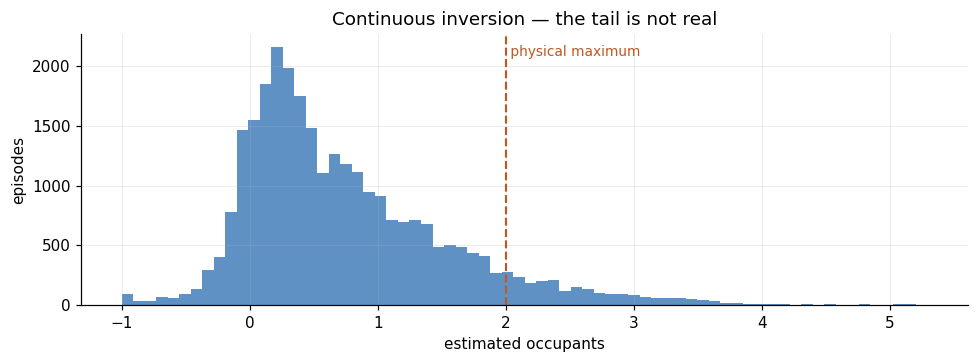

In [2]:
continuous = estimate_occupancy(data, k)["n_smooth"].dropna()
print(f"continuous estimate:  median {continuous.median():.2f}   p99 {continuous.quantile(.99):.2f}   max {continuous.max():.1f}")
print(f"share of time above 2 occupants (physically impossible here): {(continuous > 2).mean():.1%}")

fig, ax = plt.subplots(figsize=(9, 3.4))
figures.distribution(continuous.clip(-1, 6), "estimated occupants",
                     "Continuous inversion — the tail is not real", bins=70,
                     vlines=[(2, "physical maximum")], ax=ax)
plt.tight_layout(); plt.show()

## Constraining it

Occupancy here is one of {0, 1, 2} and it persists — people do not blink in and
out every five minutes. That turns an ill-posed inversion into a search over a
finite set of sequences, with the mass balance as the emission model and
Viterbi finding the path.

time spent at each occupancy: {0: '46.5%', 1: '42.4%', 2: '11.1%'}


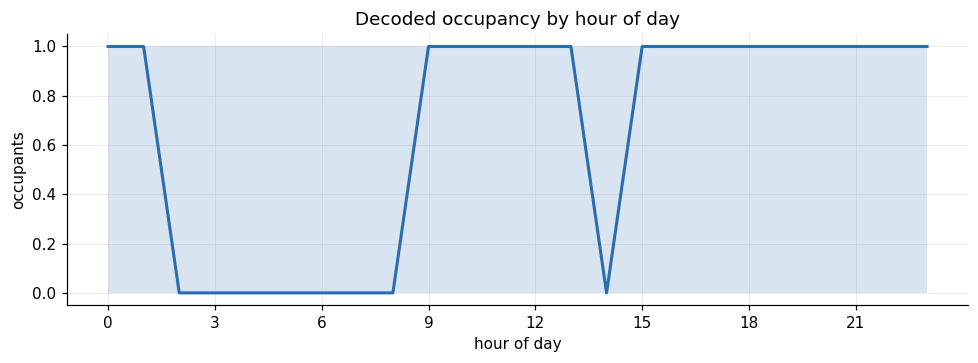

In [3]:
occ = decode(data, k, VOLUME)
share = {int(s): f"{(occ == s).mean():.1%}" for s in (0, 1, 2)}
print("time spent at each occupancy:", share)

fig, ax = plt.subplots(figsize=(9, 3.4))
figures.hour_profile(occ.astype(float), "occupants", "Decoded occupancy by hour of day", ax=ax)
plt.tight_layout(); plt.show()

## Validation without labels

There are no occupancy labels. The estimate is checked instead against periods
whose occupancy is known independently of the sensor. The windows themselves
live outside this repository, so they are reported as `period_a`…`period_e`.

In [4]:
import json
from pathlib import Path
import paths

spec_file = paths.DATA_DIR / "validation_periods.json"
labels, got, want = [], [], []
if spec_file.exists():
    hour = pd.Series(occ.index.hour, occ.index)
    dow = pd.Series(occ.index.dayofweek, occ.index)
    for name, spec in json.loads(spec_file.read_text()).items():
        m = hour.between(*spec["hours"]) & dow.isin(spec["weekdays"])
        labels.append(name)
        got.append(occ[np.asarray(m)].mean())
        want.append(float(str(spec["expected"]).split("-")[0]))
    for n, g, w in zip(labels, got, want):
        print(f"  {n:10s} estimated {g:.2f}   known {w:.0f}")
else:
    print(f"no validation windows at {spec_file}")

  period_a   estimated 0.11   known 0
  period_b   estimated 0.34   known 0
  period_c   estimated 0.88   known 1
  period_d   estimated 0.69   known 0
  period_e   estimated 1.07   known 1


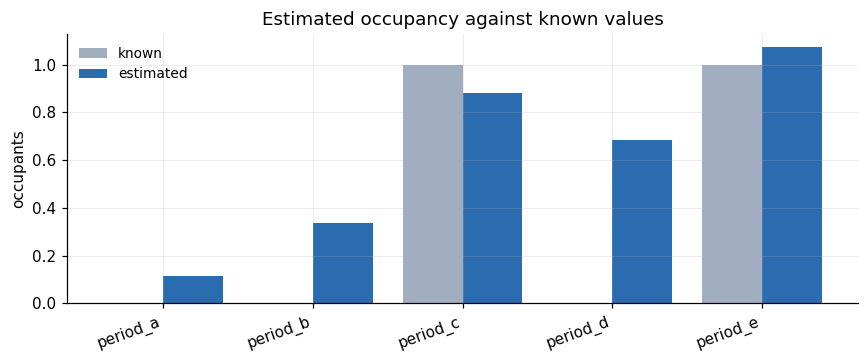

In [5]:
if labels:
    fig, ax = plt.subplots(figsize=(8, 3.4))
    figures.comparison_bars(labels, got, want, "Estimated occupancy against known values", ax=ax)
    plt.tight_layout(); plt.show()

An empty room reads 0.11 and an occupied one 0.88 against a true value of 1 —
within the uncertainty of the CO₂ generation rate, which the README quantifies.
What the model still cannot do is count reliably; see *Open problems*.